In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import librosa
import librosa.display
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
TARGET_SR = 16000
N_MFCC = 20  # Number of MFCC coefficients
N_FFT = 512
HOP_LENGTH = 160
MAX_FRAMES = 100

In [3]:
# Paths
SPLIT_DIR = '/content/drive/MyDrive/IIT/FYP/Implementation/data/Cough_Sound/data_splits'
FEATURES_DIR = '/content/drive/MyDrive/IIT/FYP/Implementation/data/Cough_Sound/mfcc_features'
os.makedirs(FEATURES_DIR, exist_ok=True)

In [4]:
print("Loading preprocessed data...")

# Load training set (augmented)
X_train = np.load(os.path.join(SPLIT_DIR, 'X_train_augmented.npy'))
y_train = np.load(os.path.join(SPLIT_DIR, 'y_train_augmented.npy'))

# Load validation set
X_val = np.load(os.path.join(SPLIT_DIR, 'X_val.npy'))
y_val = np.load(os.path.join(SPLIT_DIR, 'y_val.npy'))

# Load test set
X_test = np.load(os.path.join(SPLIT_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(SPLIT_DIR, 'y_test.npy'))

print(f"Loaded: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")


Loading preprocessed data...
Loaded: Train=1756, Val=83, Test=77


In [5]:
def print_class_distribution(y, name):
    unique, counts = np.unique(y, return_counts=True)
    dist = dict(zip(unique, counts))

    normal = dist.get(0, 0)
    pneumonia = dist.get(1, 0)

    print(f"{name} set:")
    print(f"  Normal (0): {normal}")
    print(f"  Pneumonia (1): {pneumonia}")
    print(f"  Total: {len(y)}\n")


print_class_distribution(y_train, "Train")
print_class_distribution(y_val, "Validation")
print_class_distribution(y_test, "Test")

Train set:
  Normal (0): 864
  Pneumonia (1): 892
  Total: 1756

Validation set:
  Normal (0): 48
  Pneumonia (1): 35
  Total: 83

Test set:
  Normal (0): 36
  Pneumonia (1): 41
  Total: 77



MFCC EXTRACTION FUNCTION

In [ ]:
def pad_or_truncate_mfcc(mfcc, max_len=MAX_FRAMES):
    """
    Pad or truncate MFCC to fixed length

    Args:
        mfcc: MFCC features of shape (time_steps, n_features)
        max_len: Target length for time dimension

    Returns:
        mfcc_fixed: MFCC of shape (max_len, n_features)
    """
    current_len = mfcc.shape[0]

    if current_len < max_len:
        # Pad with zeros
        pad_width = max_len - current_len
        mfcc_padded = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
        return mfcc_padded
    elif current_len > max_len:
        # Truncate
        return mfcc[:max_len]
    else:
        return mfcc

def extract_mfcc_features(audio, sr=16000, n_mfcc=20, max_len=MAX_FRAMES):
    """
    Extract MFCC features with delta and delta-delta, then pad/truncate to fixed length

    Args:
        audio: Audio signal array
        sr: Sample rate
        n_mfcc: Number of MFCC coefficients
        max_len: Fixed length for time dimension

    Returns:
        features: Array of shape (max_len, n_mfcc * 3)
    """
    # Extract MFCC coefficients
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc,
                                n_fft=N_FFT, hop_length=HOP_LENGTH)

    # Extract delta and delta-delta
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # Concatenate all features
    features = np.concatenate([mfcc, mfcc_delta, mfcc_delta2], axis=0)

    # Transpose to (time_steps, features)
    features = features.T

    # Pad or truncate to fixed length
    features_fixed = pad_or_truncate_mfcc(features, max_len=max_len)

    return features_fixed

EXTRACT MFCC FOR ALL SETS

In [ ]:
# Training set
X_train_mfcc = []
for audio in tqdm(X_train, desc="Training"):
    mfcc_features = extract_mfcc_features(audio, sr=TARGET_SR, n_mfcc=N_MFCC)
    X_train_mfcc.append(mfcc_features)
X_train_mfcc = np.array(X_train_mfcc)

# Validation set
X_val_mfcc = []
for audio in tqdm(X_val, desc="Validation"):
    mfcc_features = extract_mfcc_features(audio, sr=TARGET_SR, n_mfcc=N_MFCC)
    X_val_mfcc.append(mfcc_features)
X_val_mfcc = np.array(X_val_mfcc)

# Test set
X_test_mfcc = []
for audio in tqdm(X_test, desc="Test"):
    mfcc_features = extract_mfcc_features(audio, sr=TARGET_SR, n_mfcc=N_MFCC)
    X_test_mfcc.append(mfcc_features)
X_test_mfcc = np.array(X_test_mfcc)

Test: 100%|██████████| 77/77 [00:00<00:00, 130.90it/s]


In [ ]:
np.save(os.path.join(FEATURES_DIR, 'X_train_mfcc.npy'), X_train_mfcc)
np.save(os.path.join(FEATURES_DIR, 'y_train.npy'), y_train)

np.save(os.path.join(FEATURES_DIR, 'X_val_mfcc.npy'), X_val_mfcc)
np.save(os.path.join(FEATURES_DIR, 'y_val.npy'), y_val)

np.save(os.path.join(FEATURES_DIR, 'X_test_mfcc.npy'), X_test_mfcc)
np.save(os.path.join(FEATURES_DIR, 'y_test.npy'), y_test)

In [ ]:
print(f"\n{'='*60}")
print("SHAPE VERIFICATION")
print(f"{'='*60}")
print(f"Training: {X_train_mfcc.shape}")
print(f"Validation: {X_val_mfcc.shape}")
print(f"Test: {X_test_mfcc.shape}")
print(f"Expected shape: (samples, {MAX_FRAMES}, {N_MFCC * 3})")
print(f"All correct: {X_train_mfcc.shape[1:] == (MAX_FRAMES, N_MFCC * 3)}")

# Check data type (should be float, not object)
print(f"\nData types:")
print(f"  Train dtype: {X_train_mfcc.dtype}")
print(f"  Val dtype: {X_val_mfcc.dtype}")
print(f"  Test dtype: {X_test_mfcc.dtype}")
print(f"  All float32/64: {X_train_mfcc.dtype in [np.float32, np.float64]}")


SHAPE VERIFICATION
Training: (1756, 100, 60)
Validation: (83, 100, 60)
Test: (77, 100, 60)
Expected shape: (samples, 100, 60)
All correct: True

Data types:
  Train dtype: float32
  Val dtype: float32
  Test dtype: float32
  All float32/64: True


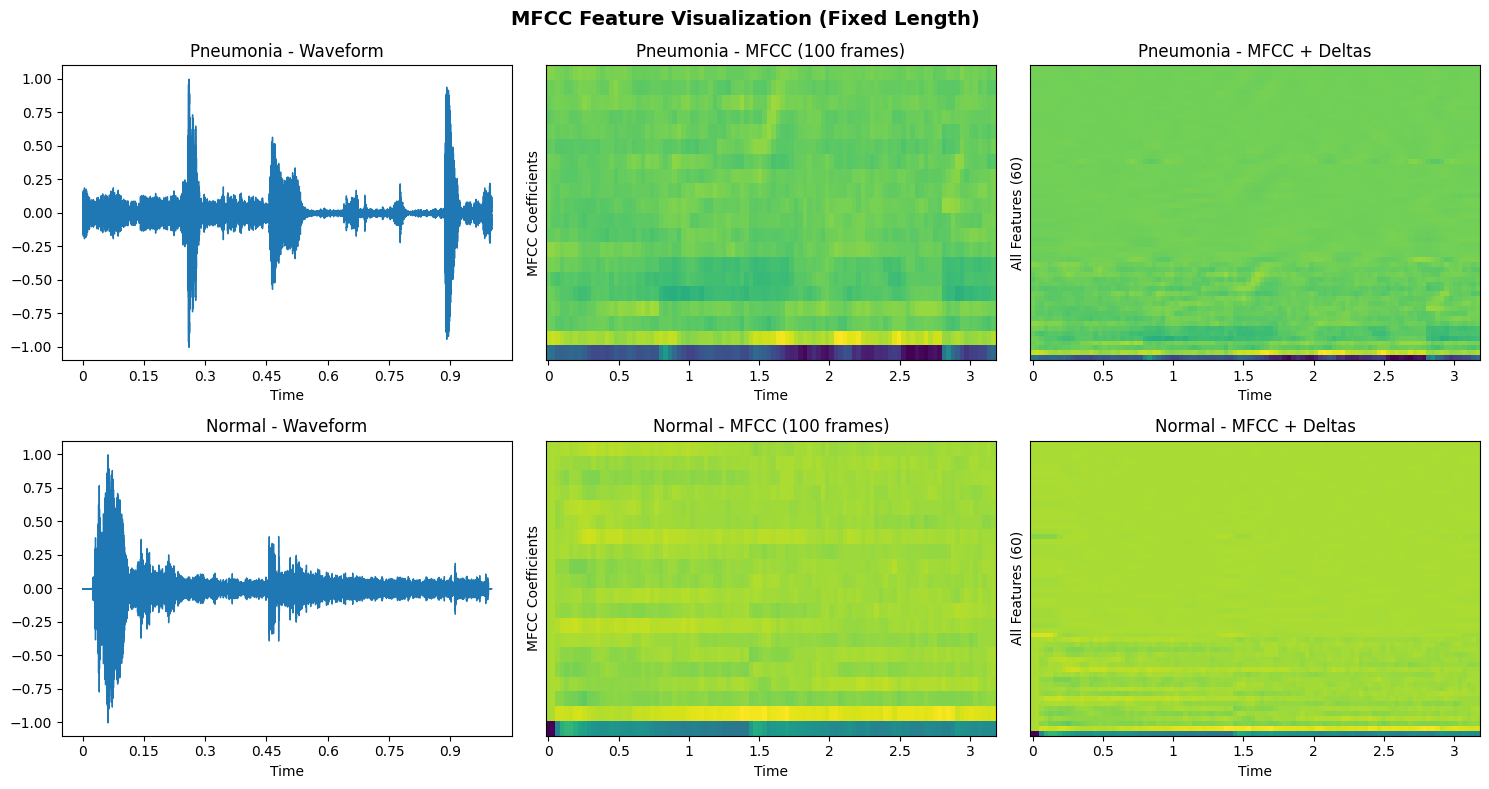

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('MFCC Feature Visualization (Fixed Length)', fontweight='bold', fontsize=14)

# Get sample indices
pneumonia_idx = np.where(y_train == 1)[0][0]
normal_idx = np.where(y_train == 0)[0][0]

# Row 1: Pneumonia
librosa.display.waveshow(X_train[pneumonia_idx], sr=TARGET_SR, ax=axes[0,0])
axes[0,0].set_title('Pneumonia - Waveform')

mfcc_only = X_train_mfcc[pneumonia_idx][:, :N_MFCC].T
librosa.display.specshow(mfcc_only, sr=TARGET_SR, x_axis='time', ax=axes[0,1], cmap='viridis')
axes[0,1].set_title(f'Pneumonia - MFCC ({MAX_FRAMES} frames)')
axes[0,1].set_ylabel('MFCC Coefficients')

librosa.display.specshow(X_train_mfcc[pneumonia_idx].T, sr=TARGET_SR, x_axis='time', ax=axes[0,2], cmap='viridis')
axes[0,2].set_title('Pneumonia - MFCC + Deltas')
axes[0,2].set_ylabel('All Features (60)')

# Row 2: Normal
librosa.display.waveshow(X_train[normal_idx], sr=TARGET_SR, ax=axes[1,0])
axes[1,0].set_title('Normal - Waveform')

mfcc_only = X_train_mfcc[normal_idx][:, :N_MFCC].T
librosa.display.specshow(mfcc_only, sr=TARGET_SR, x_axis='time', ax=axes[1,1], cmap='viridis')
axes[1,1].set_title(f'Normal - MFCC ({MAX_FRAMES} frames)')
axes[1,1].set_ylabel('MFCC Coefficients')

librosa.display.specshow(X_train_mfcc[normal_idx].T, sr=TARGET_SR, x_axis='time', ax=axes[1,2], cmap='viridis')
axes[1,2].set_title('Normal - MFCC + Deltas')
axes[1,2].set_ylabel('All Features (60)')

plt.tight_layout()
plt.show()